EDA Implementation:
Exploratory Data Analysis (EDA) is the crucial first step where you use charts and basic math to deeply understand your data before making any big decisions.  

In [1]:
#Import all required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("Imported All Libraries Successfully")

Imported All Libraries Successfully


In [2]:
#Load dataset
df = pd.read_csv("../data/hotel_bookings.csv")
print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [3]:
#Dataset shape
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 119390
Number of columns: 32


In [4]:
#First few records
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [5]:
#Datatypes of fields present in dataset -> Dataset Audit
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [6]:
#Missing Value Count
missing_df = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": df.isnull().mean() * 100
})

missing_df[missing_df["Missing Count"] > 0].sort_values(
    "Missing Count", ascending=False
)

,Missing Count,Missing Percentage
company,112593,94.306893
agent,16340,13.686238
country,488,0.408744
children,4,0.003350


Insights for Missing Values:
The dataset contains substantial missing values in company and agent, while only a small number of records have missing children and country values. These missing values require different treatment based on the meaning of each variable.

In [7]:
#Duplicate Records
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 31994


Insights for Duplicates
The dataset contains 31,994 exact duplicate rows. Duplicate records can bias the analysis and model training, so they will be investigated and removed during preprocessing.

In [8]:
#Target variable of classification problem
Target = "is_canceled"
y = df[Target]
print(y.value_counts())
print(y.value_counts(normalize=True) * 100)

is_canceled
0    75166
1    44224
Name: count, dtype: int64
is_canceled
0    62.958372
1    37.041628
Name: proportion, dtype: float64


Insights for Target Distribution:
The target variable is_canceled contains two classes representing canceled and non-canceled bookings. The class distribution should be considered during model training because an imbalanced target can affect classification performance.

EDA Visualisations:
Distribution plots for each feature, correlation heatmap, target distribution, and at least two scatter plots showing feature relationships.

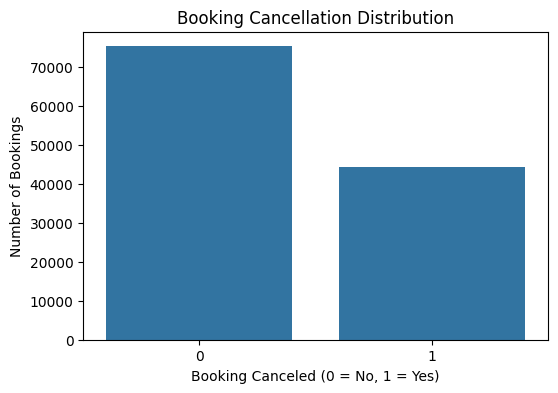

is_canceled
0    62.96
1    37.04
Name: proportion, dtype: float64

In [9]:
#1.Target distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="is_canceled")
plt.title("Booking Cancellation Distribution")
plt.xlabel("Booking Canceled (0 = No, 1 = Yes)")
plt.ylabel("Number of Bookings")
plt.show()
df["is_canceled"].value_counts(normalize=True).mul(100).round(2)

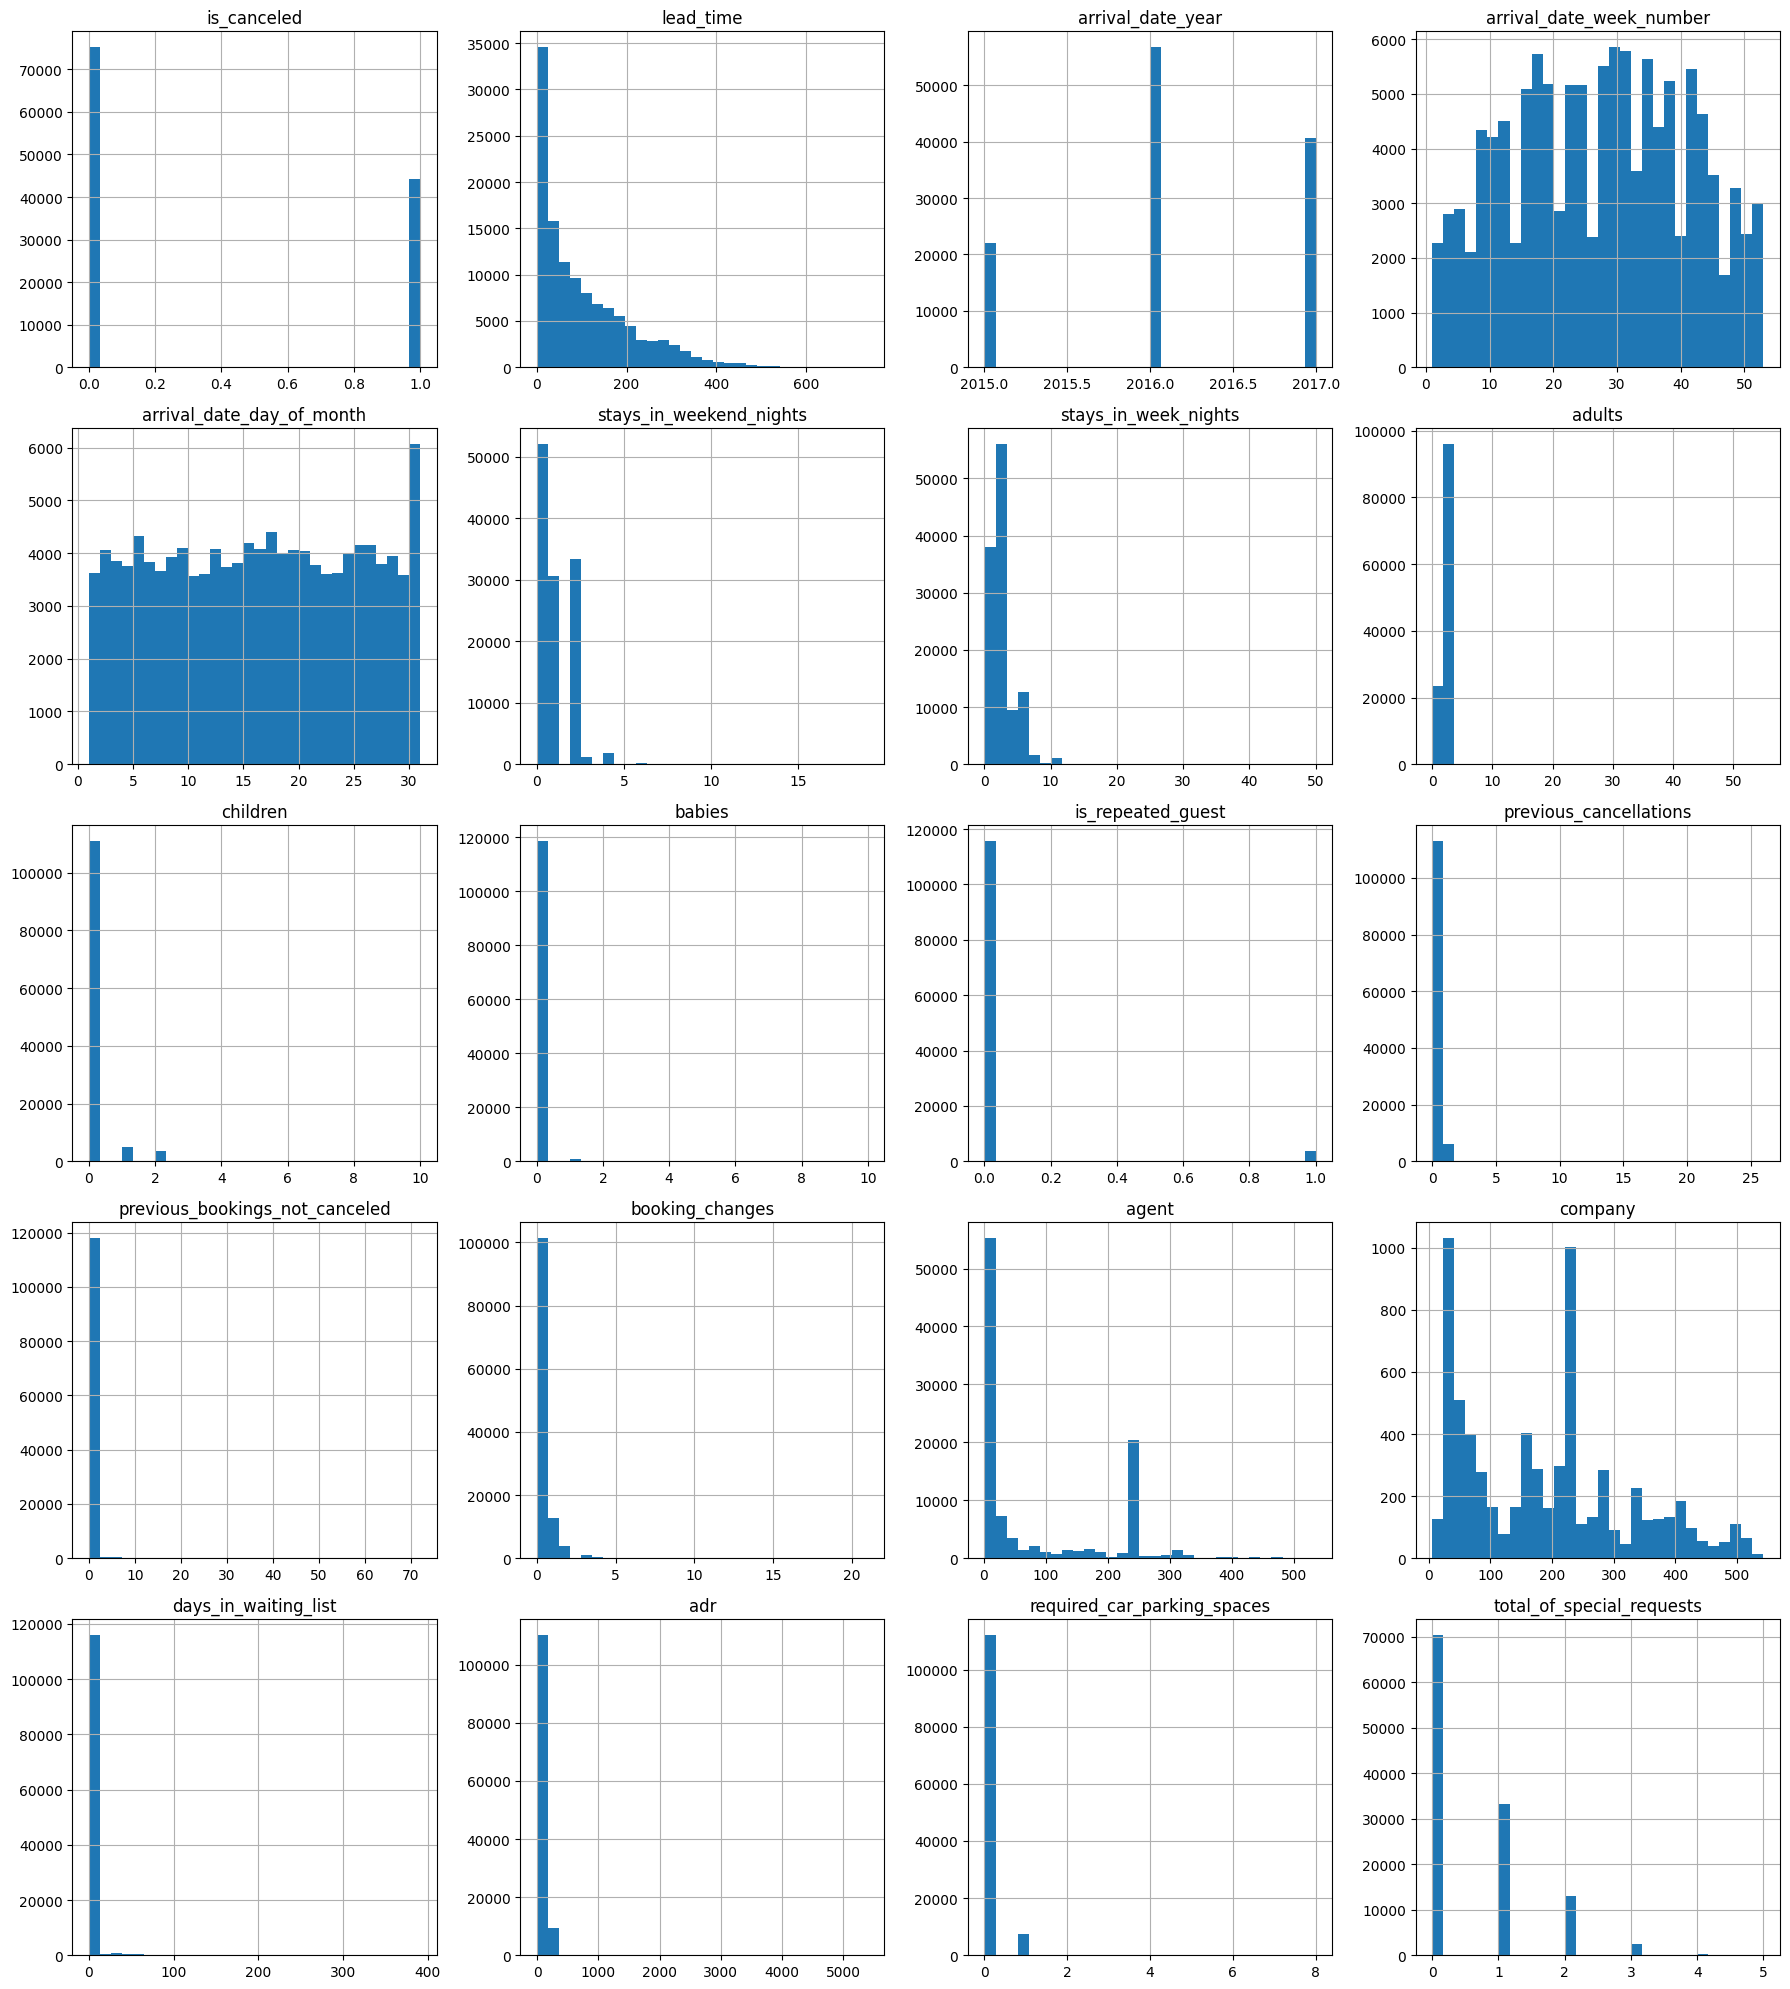

In [10]:
#2. Numerical feature distributions
numeric_cols = df.select_dtypes(include=np.number).columns

df[numeric_cols].hist(
    figsize=(18, 20),
    bins=30
)

plt.tight_layout()
plt.show()

C:\Users\manin\AppData\Local\Temp\ipykernel_28332\3186742069.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns


Index(['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment',
       'distribution_channel', 'reserved_room_type', 'assigned_room_type',
       'deposit_type', 'customer_type', 'reservation_status',
       'reservation_status_date'],
      dtype='str')


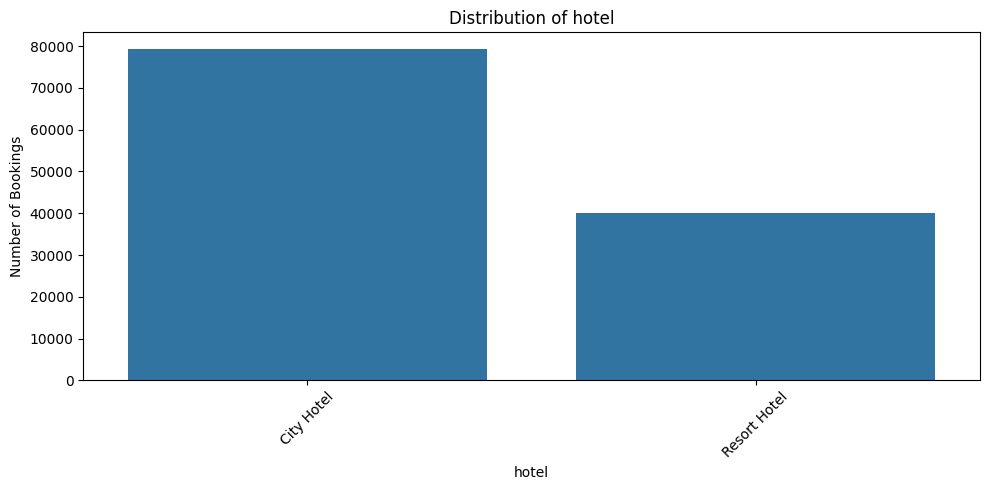

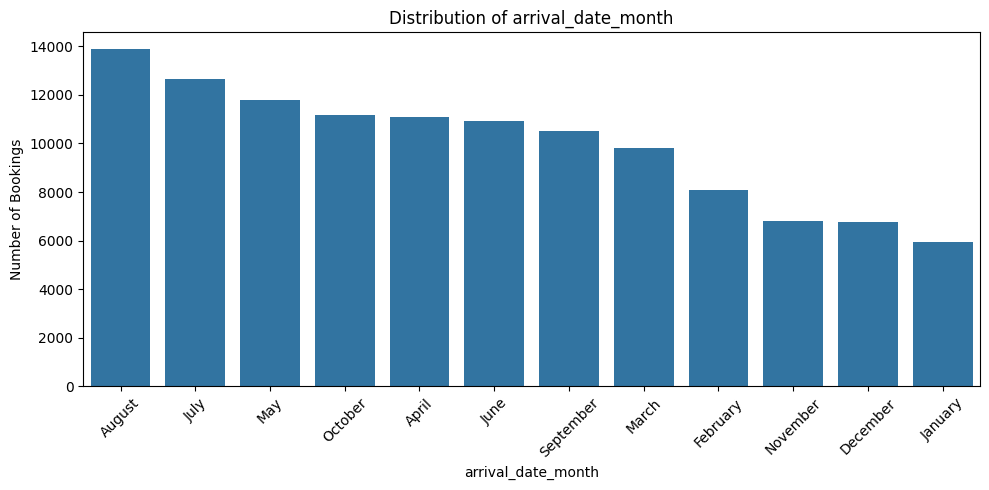

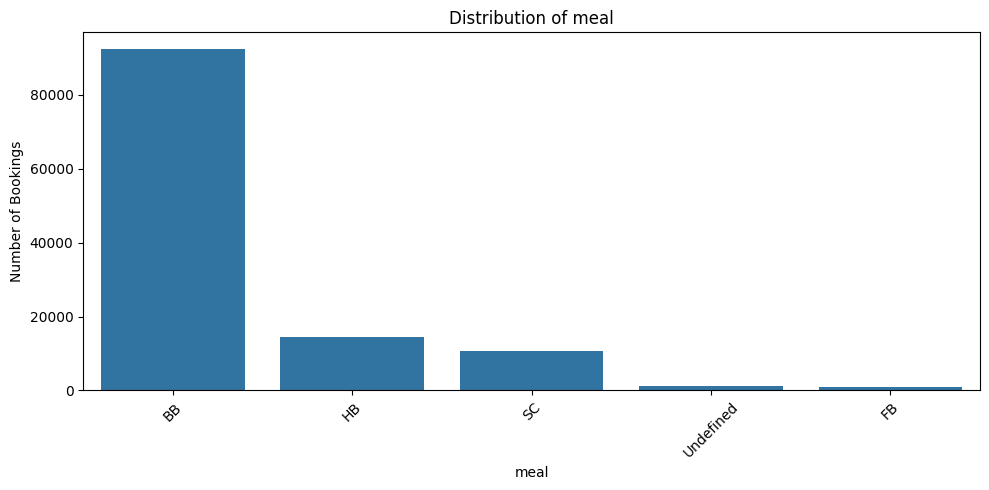

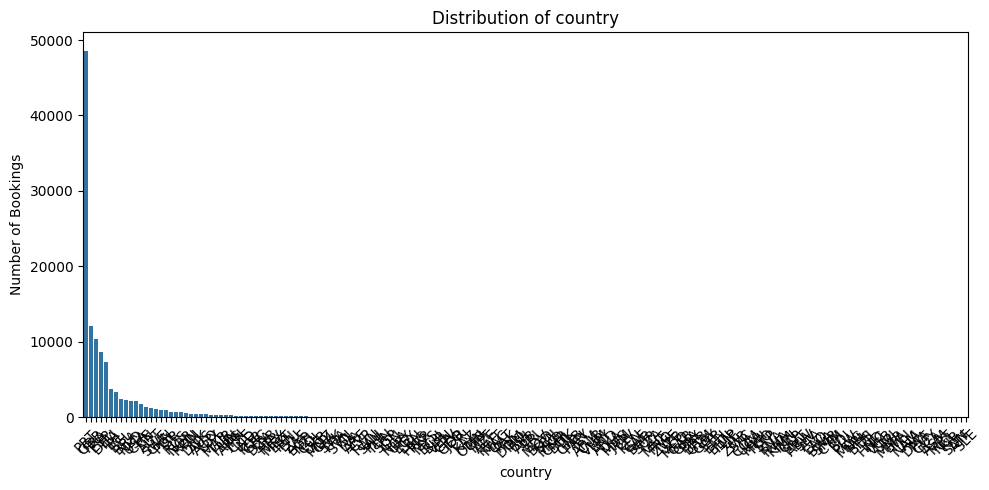

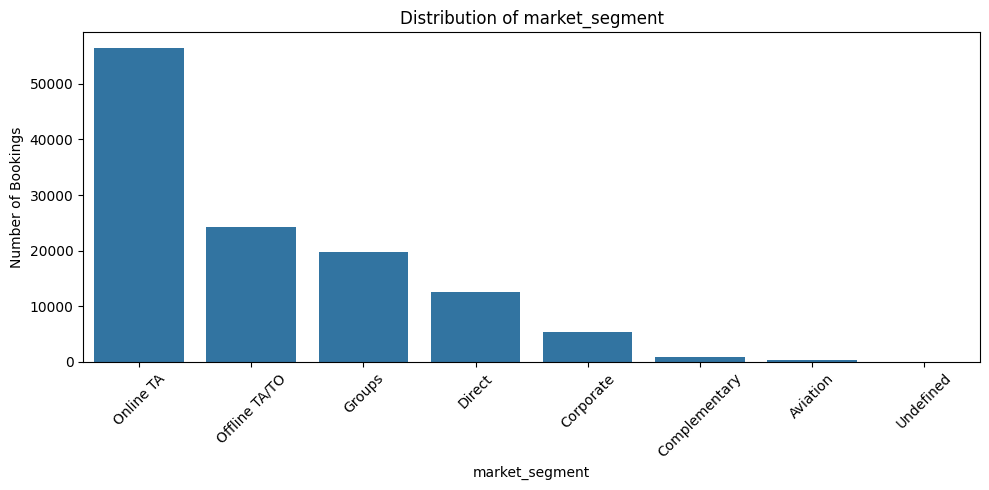

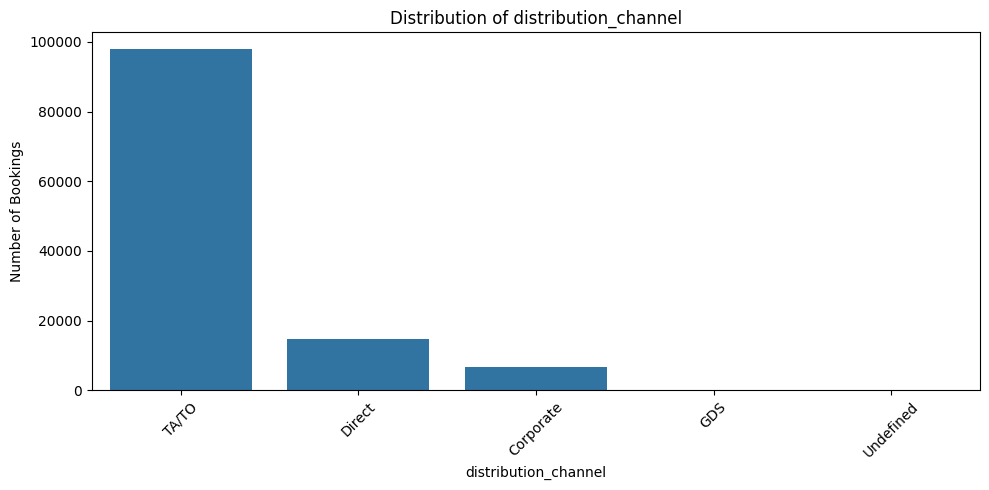

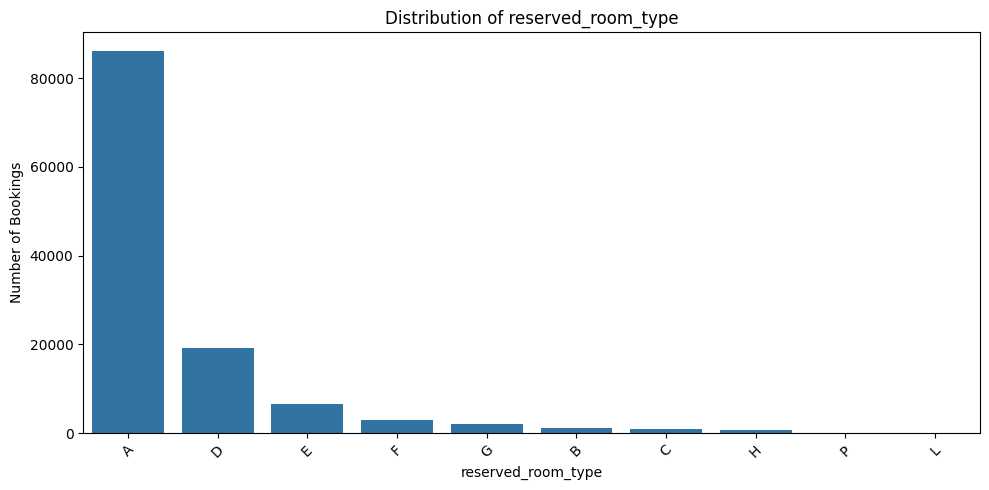

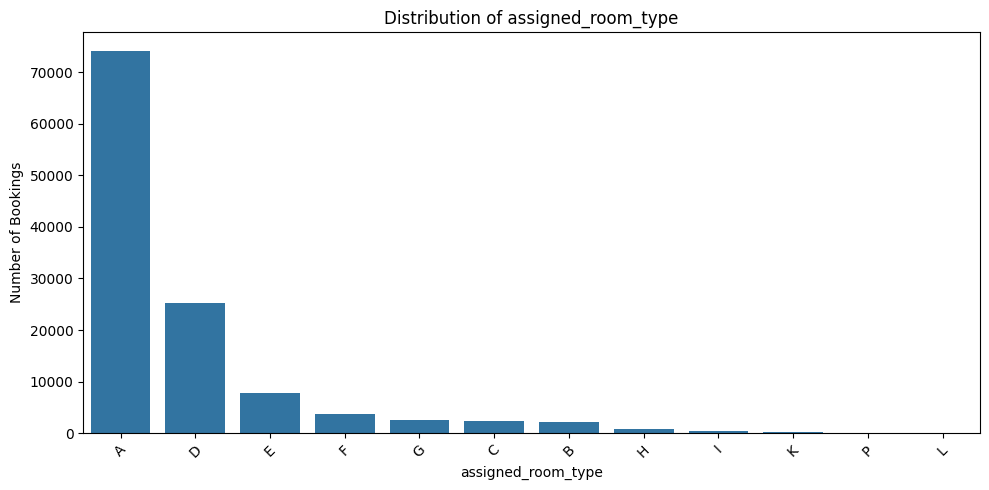

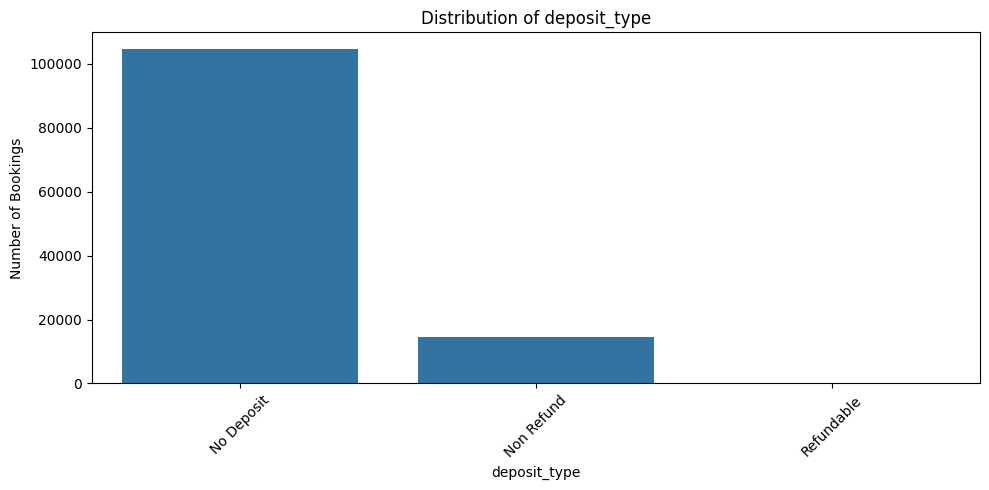

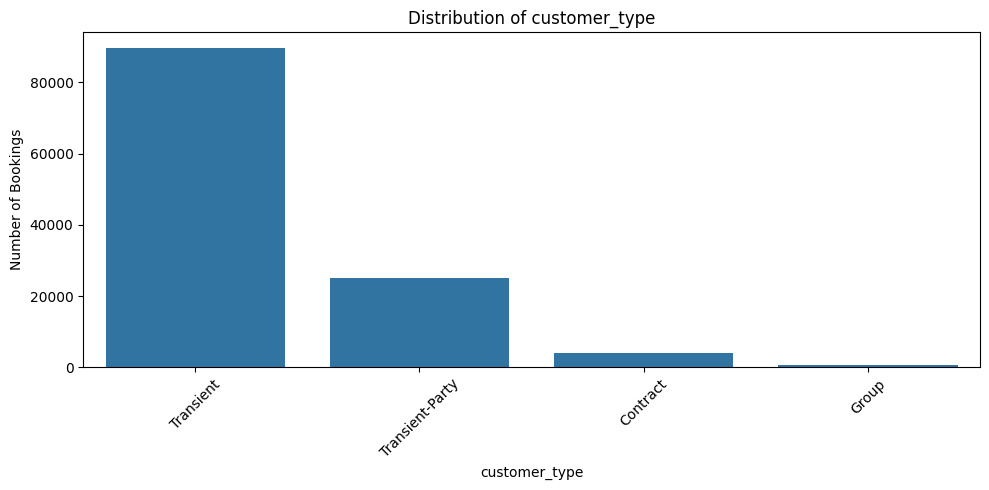

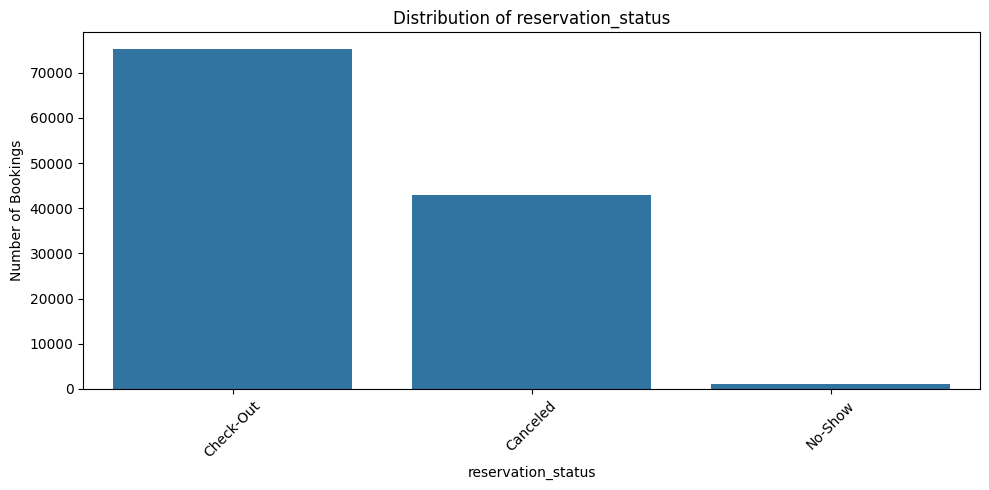

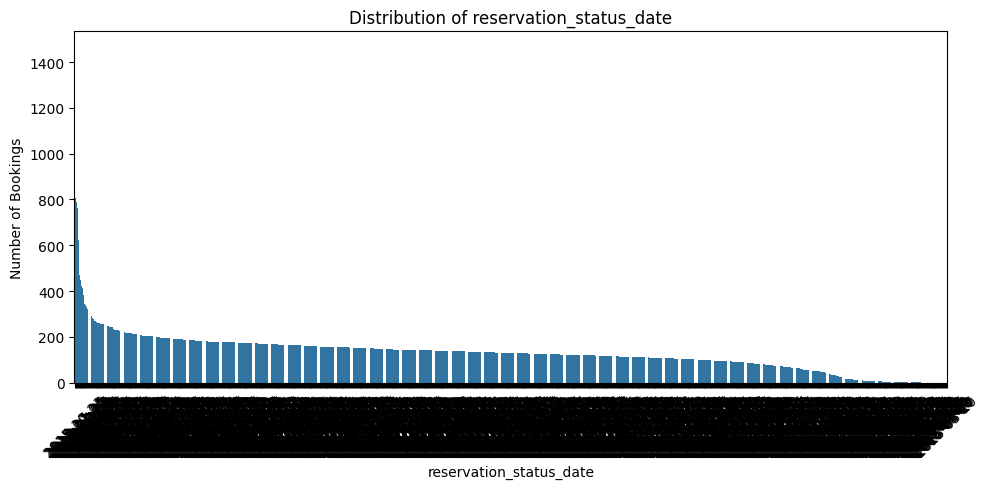

In [ ]:
#3.Categorical feature distributions
categorical_cols = df.select_dtypes(include="object").columns
print(categorical_cols)

#Count Plots
for col in categorical_cols:
    plt.figure(figsize=(10, 5))
    
    sns.countplot(
        data=df,
        x=col,
        order=df[col].value_counts().index
    )
    
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Number of Bookings")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

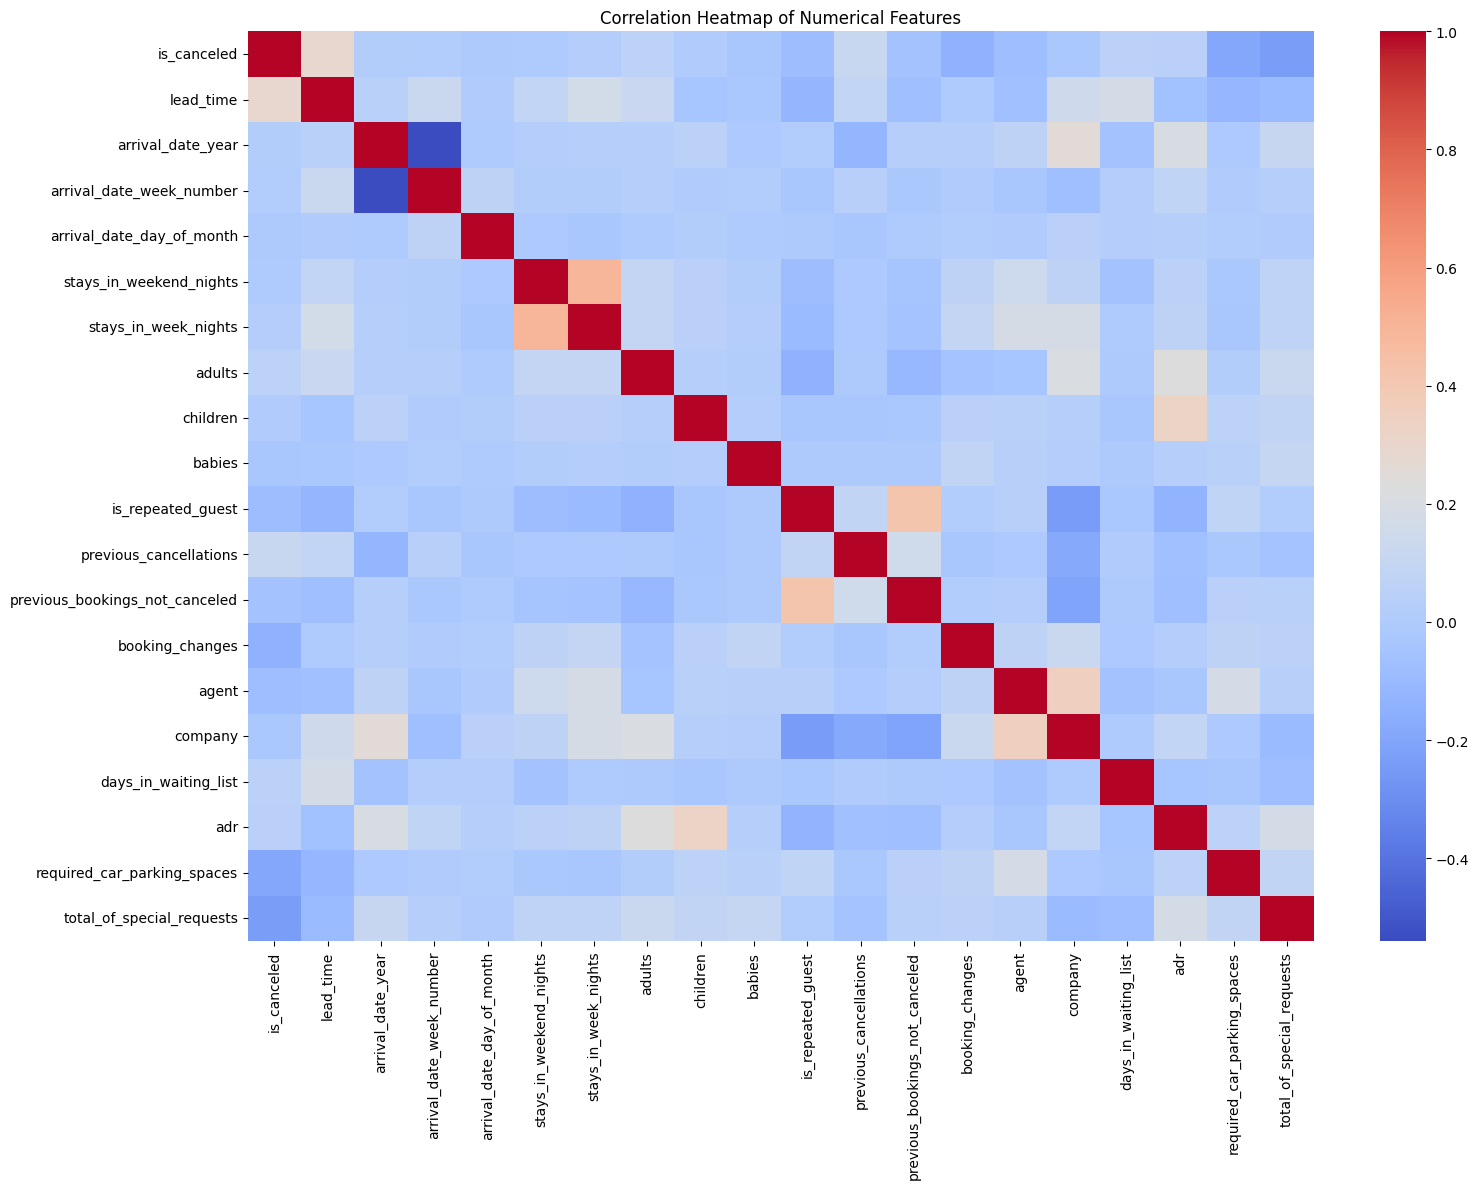

In [12]:
#4. Correlation heatmap
plt.figure(figsize=(16, 12))

correlation = df.select_dtypes(include=np.number).corr()

sns.heatmap(
    correlation,
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

Insight for heatmap:
The correlation heatmap helps identify relationships between numerical variables and potential redundancy between features. Highly related variables will be considered during feature selection and modeling.

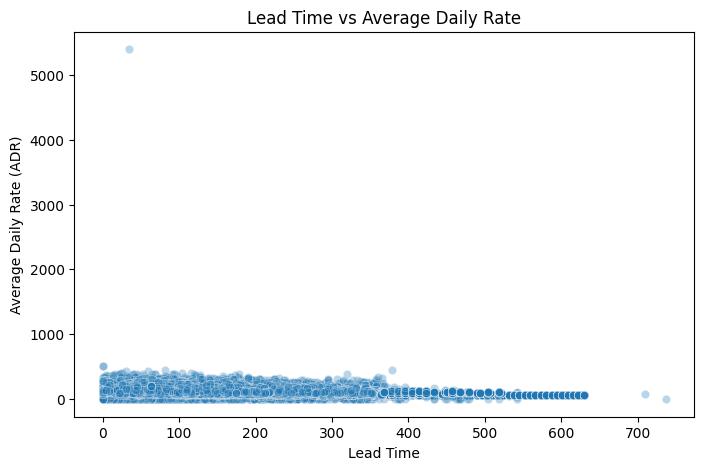

In [13]:
#5.Scatter plot 1 — Lead Time vs ADR
#Tells Relationships for Hotel Bookings
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="lead_time",
    y="adr",
    alpha=0.3
)

plt.title("Lead Time vs Average Daily Rate")
plt.xlabel("Lead Time")
plt.ylabel("Average Daily Rate (ADR)")

plt.show()

Insight: 
The scatter plot shows how the average daily rate varies with the number of days between booking and arrival. The points are widely distributed, indicating that lead time alone does not completely determine the room rate.

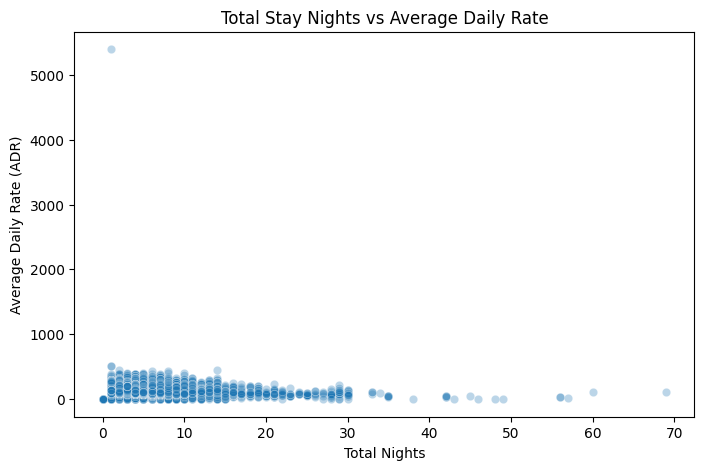

In [14]:
#6.Scatter plot 2 — Total Stay vs ADR
#Creating feature
df["total_nights"] = (
    df["stays_in_weekend_nights"] +
    df["stays_in_week_nights"]
)
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="total_nights",
    y="adr",
    alpha=0.3
)

plt.title("Total Stay Nights vs Average Daily Rate")
plt.xlabel("Total Nights")
plt.ylabel("Average Daily Rate (ADR)")

plt.show()

Insight: 
The plot shows the relationship between the length of stay and ADR. The distribution of points indicates that room rate varies across different stay durations rather than increasing uniformly with the number of nights.